In [2]:
import torch
import random
# Uses LLM to convert the device from cpu to gpu and all the .to(device) wherever you see are written by taking help of LLM
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# Loading data from hugging face
import pandas as pd

splits = {'train': 'small/train-00000-of-00001.parquet', 'validation': 'small/validation-00000-of-00001.parquet', 'test': 'small/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["train"])

In [4]:
print(df.iloc[1,1])
print(df.iloc[1,2])

public boolean METHOD_1 ( java.lang.String name ) { TYPE_1 VAR_1 = TYPE_1 . METHOD_2 ( VAR_2 ) ; return ( ! ( METHOD_3 ( name ) ) ) && ( VAR_1 . contains ( name ) ) ; } 

public boolean METHOD_1 ( java.lang.String name ) { return ( ! ( METHOD_3 ( name ) ) ) && ( TYPE_1 . METHOD_2 ( VAR_2 ) . contains ( name ) ) ; } 



In [5]:
## Tokenizer
X=df.iloc[:,1].copy()
y=df.iloc[:,2].copy()
combined_df=pd.concat([X,y])
all_words=[]

# By using the code below I got to know the total number of tokens in the dataset
# I used the in built tokenizer in Tensor flow library and I think it's a whitespace tokenization

# for buggy in X:
#   words=buggy.split()
#   for i in words:
#     all_words.append(i)
# for correct in y:
#   words=correct.split()
#   for i in words:
#     all_words.append(i)
# all_words=list(set(all_words))

In [6]:
# Importing reqired modules and initializing tokenizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Got to know about this by using LLM

tokenizer = Tokenizer(num_words=429,lower=False,oov_token='<OOV>')
tokenizer.fit_on_texts(combined_df)
sequences=tokenizer.texts_to_sequences(combined_df)
padded_sequences=pad_sequences(sequences,maxlen=60,padding='post',value=0)

In [7]:
# Loop to find the maximum length of sequence
max_len=0
for i in sequences:
  if max_len<len(i):
    max_len=len(i)
print(max_len)
print(len(padded_sequences))

60
93360


In [8]:
X=padded_sequences[:46680]
y=padded_sequences[46680:]
print(X.shape , y.shape)

(46680, 60) (46680, 60)


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader
import random

In [10]:
## Making train test and validation split
from sklearn.model_selection import train_test_split
X_train , X_t , y_train , y_t = train_test_split(X,y,test_size=0.3,random_state=42)
X_test , X_val , y_test , y_val =train_test_split(X_t,y_t,test_size=0.5,random_state=42)

X_train = torch.tensor(X_train,dtype=torch.long).to(device)
X_test = torch.tensor(X_test,dtype=torch.long).to(device)
X_val = torch.tensor(X_val,dtype=torch.long).to(device)
y_train = torch.tensor(y_train,dtype=torch.long).to(device)
y_test=torch.tensor(y_test,dtype=torch.long).to(device)
y_val = torch.tensor(y_val,dtype=torch.long).to(device)

print(X_train.shape , X_test.shape , X_val.shape)

torch.Size([32676, 60]) torch.Size([7002, 60]) torch.Size([7002, 60])


In [11]:
# Embedding class
class Embeddings(nn.Module):
  def __init__(self,input_dim=429,emb_dim=128):
    super().__init__()
    self.emb=nn.Embedding(input_dim,emb_dim)
  def forward(self,x):
    x=self.emb(x)
    return x

In [12]:
# Forming Batches
training_dataset=TensorDataset(X_train,y_train)
train_loader=DataLoader(training_dataset,batch_size=32)

In [13]:
## LSTM model
# Encoder class
class Encoder(nn.Module):
  def __init__(self,input_dim=128,hidden_dim=256,embeddings=Embeddings(),num_layers=1):
    super().__init__()
    self.emb=embeddings
    self.lstm=nn.LSTM(input_dim,hidden_dim,batch_first=True,num_layers=num_layers)
  def forward(self,x):
    emb=self.emb(x)
    _,(hidden,cell)=self.lstm(emb)
    return hidden , cell

In [14]:
# Decoder class
class Decoder(nn.Module):
  def __init__(self,input_dim=128,output_dim=429,hidden_dim=256,embeddings=Embeddings(),num_layers=1):
    super().__init__()
    self.emb=embeddings
    self.lstm=nn.LSTM(input_dim,hidden_dim,batch_first=True,num_layers=num_layers)
    self.fc1=nn.Linear(hidden_dim,hidden_dim)
    self.relu=nn.ReLU()
    self.fc2=nn.Linear(hidden_dim,output_dim)
  def forward(self,input_token,hidden,cell):
    emb_layer=self.emb(input_token)
    x ,(hidden ,cell)=self.lstm(emb_layer,(hidden,cell))
    x=self.fc1(x)
    x=self.relu(x)
    output=self.fc2(x)
    return output , hidden , cell

In [15]:
# Teacher forcing ratio has been introduced into this class by using LLM before it , I passed the correct input every time

class Seq2Seq(nn.Module):
  def __init__(self,encoder=Encoder(),decoder=Decoder(), teacher_forcing_ratio=0.5):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.teacher_forcing_ratio = teacher_forcing_ratio

  def forward(self,src,trg):
    # Took suppoort of LLM to make this forward loop suitable for batches , I wrote the code such that I can pass one by one sequence

    batch_size = trg.shape[0]
    trg_seq_len = trg.shape[1]
    hidden_encoder, cell_encoder = self.encoder(src)
    outputs = []
    decoder_input = torch.full((batch_size,1),0,dtype=torch.long,device=src.device)
    for t in range(trg_seq_len):
      output, hidden_encoder, cell_encoder = self.decoder(decoder_input, hidden_encoder, cell_encoder)
      outputs.append(output)
      teacher_force = random.random() < self.teacher_forcing_ratio

      if teacher_force:
        decoder_input = trg[:, t].unsqueeze(1)
      else:
        top1 = output.argmax(2)
        decoder_input = top1.detach()

    return torch.cat(outputs, dim=1)

In [16]:
# Single layered LSTM
model1=Seq2Seq().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model1.parameters(),lr=0.0001)

In [ ]:
## Training loop
model1.train()
for epoch in range(25):
  total_loss=0
  optimizer.zero_grad()
  for X_batch , y_batch in train_loader:
    X_batch1=X_batch.to(device)
    y_batch1=y_batch.to(device)
    output=model1(X_batch1,y_batch1)
    loss=criterion(output.view(-1,output.shape[-1]),y_batch.view(-1))
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"Epoch {epoch+1} : {total_loss}")

Epoch 1 : 614.7331136465073
Epoch 2 : 600.3337273597717
Epoch 3 : 585.5606518685818
Epoch 4 : 572.0597213506699
Epoch 5 : 558.0595511496067
Epoch 6 : 548.1023212075233
Epoch 7 : 536.8263548016548
Epoch 8 : 529.6178788542747
Epoch 9 : 517.3956766724586
Epoch 10 : 507.5061900317669
Epoch 11 : 487.0665566921234
Epoch 12 : 466.90085396170616
Epoch 13 : 459.56874945759773
Epoch 14 : 454.05575770139694
Epoch 15 : 443.48724937438965
Epoch 16 : 437.1005924642086
Epoch 17 : 430.4291840493679
Epoch 18 : 425.82539215683937
Epoch 19 : 419.48285588622093
Epoch 20 : 411.9429025352001
Epoch 21 : 403.6200298964977
Epoch 22 : 398.63783752918243
Epoch 23 : 398.1856082677841
Epoch 24 : 393.7527731359005
Epoch 25 : 388.6449778974056


In [ ]:
# Evaluation Loop
model1.eval()
testing_dataset=TensorDataset(X_test,y_test)
testing_loader=DataLoader(testing_dataset)
correct_pred=0
total_pred=0
with torch.no_grad():
  for X_batch , y_batch in testing_loader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)
    hidden_encoder,cell_encoder=model1.encoder(X_batch)
    batch_size=y_batch.shape[0]
    trg_seq_len=y_batch.shape[1]
    decoder_input = torch.full((batch_size,1),0,dtype=torch.long,device=device)
    for t in range(trg_seq_len):
      output , hidden , cell=model1.decoder(decoder_input,hidden_encoder,cell_encoder)
      out=torch.argmax(output,dim=-1)
      decoder_input=out
      correct_pred+=(out.squeeze(1)==y_batch[:,t]).sum().item()
      total_pred+=batch_size
  print(f"Accuracy : {correct_pred*100/total_pred}")

Accuracy : 6.450537941540512


In [ ]:
print(out , total_pred)

tensor([[4]], device='cuda:0') 420120


In [17]:
## Multi Layered LSTM
model2=Seq2Seq(encoder=Encoder(num_layers=4),decoder=Decoder(num_layers=4)).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model2.parameters(),lr=0.00001)

In [ ]:
## Training loop
model2.train()
for epoch in range(25):
  total_loss=0
  for X_batch , y_batch in train_loader:
    optimizer.zero_grad()
    X_batch1=X_batch.to(device)
    y_batch1=y_batch.to(device)
    output=model2(X_batch1,y_batch1)
    loss=criterion(output.view(-1,output.shape[-1]),y_batch.view(-1))
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"Epoch {epoch+1} : {total_loss}")

Epoch 1 : 2670.6073915958405
Epoch 2 : 1419.331200659275
Epoch 3 : 1361.1852273344994
Epoch 4 : 1383.8132591843605
Epoch 5 : 1431.5582467317581
Epoch 6 : 1399.1363489031792
Epoch 7 : 1265.6028724312782
Epoch 8 : 1303.288937151432
Epoch 9 : 1263.5694807767868
Epoch 10 : 1241.5147821307182
Epoch 11 : 1245.9605360031128
Epoch 12 : 1251.4833552241325
Epoch 13 : 1222.0523943305016
Epoch 14 : 1196.4309064745903
Epoch 15 : 1145.8416444063187
Epoch 16 : 1117.8209219574928
Epoch 17 : 1124.736072063446
Epoch 18 : 1141.3780376911163
Epoch 19 : 1059.6947033405304
Epoch 20 : 1019.0534106492996
Epoch 21 : 975.8588927984238
Epoch 22 : 967.8351212739944
Epoch 23 : 932.2706534862518
Epoch 24 : 917.8798527121544
Epoch 25 : 906.8946818709373


In [ ]:
# Evaluation loop
model2.eval()
correct_pred=0
total_pred=0
testing_dataset=TensorDataset(X_test,y_test)
testing_loader=DataLoader(testing_dataset)
with torch.no_grad():
  for X_batch , y_batch in testing_loader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)
    hidden_encoder,cell_encoder=model2.encoder(X_batch)
    batch_size=y_batch.shape[0]
    trg_seq_len=y_batch.shape[1]
    decoder_input = torch.full((batch_size,1),0,dtype=torch.long,device=device)
    for t in range(trg_seq_len):
      output , hidden , cell=model2.decoder(decoder_input,hidden_encoder,cell_encoder)
      out=torch.argmax(output,dim=-1)
      decoder_input=out
      correct_pred+=(out.squeeze(1)==y_batch[:,t]).sum().item()
      total_pred+=batch_size
  print(f"Accuracy : {correct_pred*100/total_pred}")

Accuracy : 1.2965343235266114


In [18]:
## Encoder Decoder Transformer model
# Class 1 - Positional Encoding
class Positional_Encoding(nn.Module):
  def __init__(self,max_len=60,dim=128):
    super(Positional_Encoding,self).__init__()
    pe=torch.zeros(max_len,dim)
    position=torch.arange(0,60).unsqueeze(1)
    div_term=torch.exp(torch.arange(0, dim, 2).float() * -(torch.log(torch.tensor(10000.0)) / dim))
    pe[:,0::2]=torch.sin(position*div_term)
    pe[:,1::2]=torch.cos(position*div_term)
    self.register_buffer('pe',pe.unsqueeze(0))

  def forward(self,x):
    return x + self.pe[:,:x.size(1),:]

In [19]:
# Class 2 - Multi Head Attention
class Multi_Head_Attention(nn.Module):
  def __init__(self,dim=128,num_heads=16):
    super().__init__()
    self.dim=dim
    self.num_heads=16
    self.d_k=dim//num_heads

    self.w_q=nn.Linear(dim,dim)
    self.w_k=nn.Linear(dim,dim)
    self.w_v=nn.Linear(dim,dim)
    self.w_o=nn.Linear(dim,dim)

  def split_heads(self,x):
    batch_size , seq_len , d_model = x.size()
    return x.view(batch_size,seq_len,self.num_heads,self.d_k).transpose(1,2)

  def forward(self,Q,K,V,mask=None):
    Q=self.split_heads(Q)
    K=self.split_heads(K)
    V=self.split_heads(V)

    atten_scores=torch.matmul(Q,K.transpose(-2,-1)) / torch.sqrt(torch.tensor(self.d_k))
    if mask is not None :
      atten_scores=atten_scores.masked_fill(mask==0,-1e9)
    atten_weights=torch.softmax(atten_scores,dim=-1)
    sim_scores=torch.matmul(atten_weights,V)

    batch_size,num_heads,seq_len,d_k=sim_scores.size()
    sim_scores=sim_scores.transpose(1,2).contiguous().view(batch_size,seq_len,self.dim)
    output=self.w_o(sim_scores)

    return output

In [20]:
# Class 3 - Feed forward layer
class Feed_Forward_layer(nn.Module):
  def __init__(self,dim=128,dff=256):
    super().__init__()
    self.fc1=nn.Linear(dim,dff)
    self.relu=nn.ReLU()
    self.fc2=nn.Linear(dff,dim)

  def forward(self,x):
    x=self.fc1(x)
    x=self.relu(x)
    x=self.fc2(x)
    return x

In [21]:
# Class 4 Encoder
class Encoder_layer(nn.Module):
  def __init__(self,embeddings=Embeddings(),positional_enc=Positional_Encoding(),attention=Multi_Head_Attention(),feed_forward=Feed_Forward_layer()):
    super().__init__()
    self.emb=embeddings
    self.pos_enc=positional_enc
    self.atten=attention
    self.fc=feed_forward
    self.norm1=nn.LayerNorm(128)
    self.norm2=nn.LayerNorm(128)
  def forward(self,x,mask):
    x=self.emb(x)
    x_encoded=self.pos_enc(x)
    output=self.atten(x_encoded,x_encoded,x_encoded,mask)
    residual_connec=output+x_encoded
    residual_norm= self.norm1(residual_connec)
    output=self.fc(residual_norm)
    return (self.norm2(output + residual_norm))

In [26]:
# Class 5 Decoder
class Decoder_layer(nn.Module):
  def __init__(self,embeddings=Embeddings(),positional_enc=Positional_Encoding(),attention=Multi_Head_Attention(),feed_forward=Feed_Forward_layer()):
    super().__init__()
    self.emb=embeddings
    self.pos_enc=positional_enc
    self.self_attention=Multi_Head_Attention()
    self.cross_attention=Multi_Head_Attention()
    self.norm1=nn.LayerNorm(128)
    self.norm2=nn.LayerNorm(128)
    self.norm3=nn.LayerNorm(128)
    self.fc=feed_forward

  def forward(self,x,trg,x_mask,trg_mask):
    trg=self.emb(trg)
    trg_encoded=self.pos_enc(trg)
    atten_scores= self.self_attention(trg_encoded,trg_encoded,trg_encoded,trg_mask)
    trg_norm=self.norm1(trg_encoded+atten_scores)
    atten_scores=self.cross_attention(trg_norm,x,x,x_mask)
    output=self.norm2(atten_scores+trg_norm)
    output1=self.fc(output)
    return self.norm3(output1+output)

In [27]:
class Transformer(nn.Module):
  def __init__(self,num_layers=1,encoder=Encoder_layer(),decoder=Decoder_layer()):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.fc=nn.Linear(128,429)

  def generate_src_mask (self,src):
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    return src_mask

  def generate_trg_mask(self, trg):
    # Target padding mask
    pad_mask = (trg != 0).unsqueeze(1).unsqueeze(2)
    trg_len = trg.shape[1]
    casual_mask = torch.tril(torch.ones(trg_len, trg_len, device=trg.device)).bool().unsqueeze(0).unsqueeze(0) # (1, 1, trg_len, trg_len)
    trg_mask = casual_mask & pad_mask
    return trg_mask

  def forward(self,src,trg):
    src_mask  = self.generate_src_mask(src)
    enc_output = self.encoder(src,src_mask)
    trg_mask = self.generate_trg_mask(trg)
    dec_out  = self.decoder(enc_output, trg, src_mask, trg_mask)
    output = self.fc(dec_out)
    return output

In [34]:
model2=Transformer().to(device)
criterion=nn.CrossEntropyLoss(ignore_index=0) # Added ignore_index using LLM
optimizer=torch.optim.Adam(model2.parameters(),lr=0.0001)

In [35]:
## Training Loop
validation_dataset=TensorDataset(X_val,y_val)
validation_loader=DataLoader(validation_dataset)
training_losses=[]
validation_losses=[]
for epoch in range(5):
  total_loss=0
  val_loss=0
  model2.train()
  optimizer.zero_grad()
  for X_batch , y_batch in train_loader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)
    # Call forward without teacher_forcing_ratio argument
    output=model2(X_batch,y_batch)
    batch_size , seq_len , pred=output.shape
    output=output.view(batch_size*seq_len , pred)
    y_batch=y_batch.view(-1)
    loss=criterion(output,y_batch)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()

  model2.eval()
  with torch.no_grad():
    for X_batch_val , y_batch_val in validation_loader:
      X_batch_val=X_batch_val.to(device)
      y_batch_val=y_batch_val.to(device)

      # Get the output from the model for the validation batch
      val_output=model2(X_batch_val,y_batch_val)

      # Reshape for loss calculation
      batch_size_val , seq_len_val , pred_val=val_output.shape
      val_output=val_output.view(batch_size_val*seq_len_val , pred_val)
      y_batch_val=y_batch_val.view(-1)
      loss=criterion(val_output,y_batch_val)
      val_loss+=loss.item()

  print(f"Epoch Loss {epoch + 1} : {total_loss}")
  print(f"Validation loss {epoch+1}: {val_loss}")
  print()
  training_losses.append(total_loss/(X_train.shape[0]*60))
  validation_losses.append(val_loss/(X_val.shape[0]*60))

Epoch Loss 1 : 960.2738611251116
Validation loss 1: 550.3604922835366

Epoch Loss 2 : 29.266873068234418
Validation loss 2: 27.699955498745112

Epoch Loss 3 : 2.22527628345415
Validation loss 3: 5.651011481482783

Epoch Loss 4 : 0.5713874882640084
Validation loss 4: 2.1919849980740764

Epoch Loss 5 : 0.2332589995712624
Validation loss 5: 1.233985534076055



In [37]:
model2.eval()
testing_dataset = TensorDataset(X_test,y_test)
testing_loader = DataLoader(testing_dataset)
correct_pred_count = 0
total_tokens_count = 0

max_output_length = 60

with torch.no_grad():
  for batch_idx, (X_batch, y_batch) in enumerate(testing_loader):
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    batch_size = X_batch.shape[0]

    decoder_input = torch.full((batch_size, 1), 0, dtype=torch.long, device=device)

    generated_tokens = torch.zeros(batch_size, max_output_length, dtype=torch.long, device=device)
    for t in range(max_output_length):
      output = model2(X_batch, decoder_input)

      prediction_for_next_token = output[:, -1, :]

      next_token = torch.argmax(prediction_for_next_token, dim=-1)

      generated_tokens[:, t] = next_token

      decoder_input = torch.cat((decoder_input, next_token.unsqueeze(1)), dim=1)

    for i in range(batch_size):
        true_sequence_len = (y_batch[i] != 0).sum().item()

        comparison_len = min(true_sequence_len, max_output_length)

        for k in range(comparison_len):
            if generated_tokens[i, k] == y_batch[i, k]:
                correct_pred_count += 1
            total_tokens_count += 1

print(f"Accuracy : {(correct_pred_count * 100 / total_tokens_count) if total_tokens_count > 0 else 0}")

Accuracy : 1.4560287516142036


In [ ]:
print(X_train.shape , X_val.shape , X_test.shape)

torch.Size([32676, 60]) torch.Size([7002, 60]) torch.Size([7002, 60])


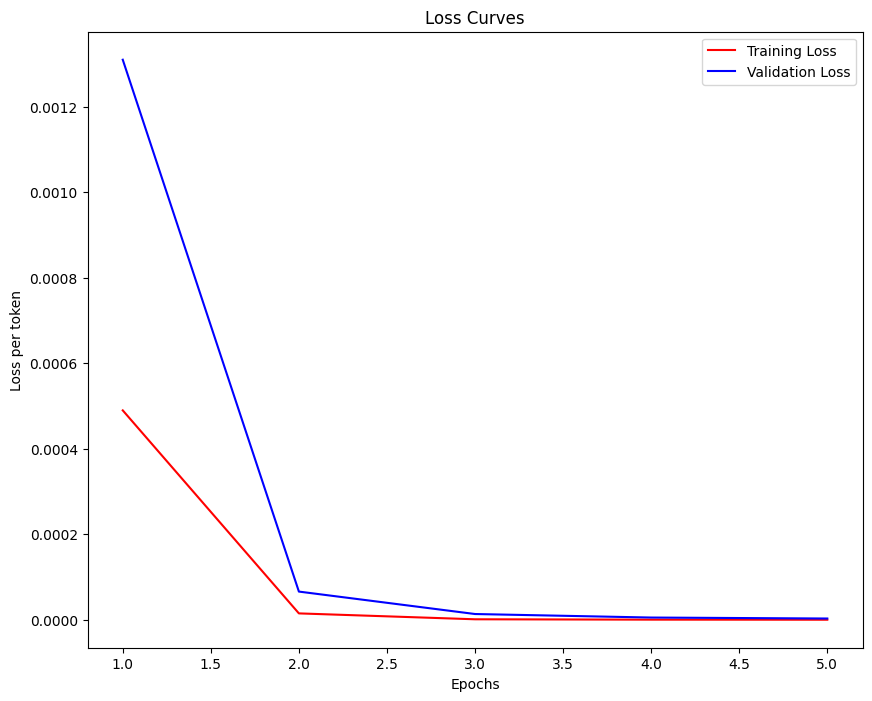

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
plt.plot([i+1 for i in range(5)] , training_losses , color='red' , label='Training Loss')
plt.plot([i+1 for i in range(5)] , validation_losses , color='blue' , label='Validation Loss')
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss per token")
plt.legend()
plt.show()

In [38]:
print(generated_tokens)

tensor([[13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13]])
